In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import ttest_ind, f_oneway, pearsonr, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('../data/processed/master_delivery_data.csv')

print("="*80)
print("STEP 8: STATISTICAL ANALYSIS & HYPOTHESIS TESTING")
print("="*80)
print(f"\nDataset: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

STEP 8: STATISTICAL ANALYSIS & HYPOTHESIS TESTING

Dataset: 180,519 rows × 60 columns



In [2]:
print("\n" + "="*80)
print("TEST 1: DOES SHIPPING MODE AFFECT DELIVERY PERFORMANCE?")
print("="*80)

print("\nBusiness Question: Do different shipping modes have significantly different delays?")
print("Null Hypothesis (H0): All shipping modes have equal average delay")
print("Alternative Hypothesis (H1): At least one shipping mode has different average delay\n")

# Prepare data by shipping mode
shipping_modes = df['Shipping Mode'].unique()
mode_delays = [df[df['Shipping Mode'] == mode]['Delay_Days'].dropna() for mode in shipping_modes]

# ANOVA Test
f_statistic, p_value = f_oneway(*mode_delays)

print("Test Used: One-Way ANOVA (Analysis of Variance)")
print(f"F-Statistic: {f_statistic:.4f}")
print(f"P-Value: {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print(f"\n✓ RESULT: SIGNIFICANT (p < 0.05)")
    print("Interpretation: Shipping modes have SIGNIFICANTLY different delivery delays.")
    print("Business Impact: We should prioritize improving worst-performing shipping methods.")
else:
    print(f"\n✗ RESULT: NOT SIGNIFICANT (p >= 0.05)")
    print("Interpretation: No significant difference in delays across shipping modes.")

# Show descriptive stats
print("\n" + "-"*80)
print("Descriptive Statistics by Shipping Mode:")
print("-"*80)
shipping_stats = df.groupby('Shipping Mode')['Delay_Days'].agg(['mean', 'std', 'count'])
print(shipping_stats)


TEST 1: DOES SHIPPING MODE AFFECT DELIVERY PERFORMANCE?

Business Question: Do different shipping modes have significantly different delays?
Null Hypothesis (H0): All shipping modes have equal average delay
Alternative Hypothesis (H1): At least one shipping mode has different average delay

Test Used: One-Way ANOVA (Analysis of Variance)
F-Statistic: 23246.0527
P-Value: 0.000000

✓ RESULT: SIGNIFICANT (p < 0.05)
Interpretation: Shipping modes have SIGNIFICANTLY different delivery delays.
Business Impact: We should prioritize improving worst-performing shipping methods.

--------------------------------------------------------------------------------
Descriptive Statistics by Shipping Mode:
--------------------------------------------------------------------------------
                    mean       std   count
Shipping Mode                             
First Class     1.000000  0.000000   27814
Same Day        0.478279  0.499554    9737
Second Class    1.990828  1.415900   35216
Stan

In [3]:
print("\n" + "="*80)
print("TEST 2: DO DIFFERENT REGIONS HAVE DIFFERENT DELIVERY PERFORMANCE?")
print("="*80)

print("\nBusiness Question: Do states have significantly different on-time delivery rates?")
print("Null Hypothesis (H0): All states have equal late delivery rates")
print("Alternative Hypothesis (H1): At least one state has different late delivery rate\n")

# Get top 10 states
top_states = df['Customer State'].value_counts().head(10).index
df_top_states = df[df['Customer State'].isin(top_states)]

# Prepare data by state
state_delays = [df_top_states[df_top_states['Customer State'] == state]['Delay_Days'].dropna() 
                for state in top_states]

# ANOVA Test
f_statistic, p_value = f_oneway(*state_delays)

print("Test Used: One-Way ANOVA")
print(f"F-Statistic: {f_statistic:.4f}")
print(f"P-Value: {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print(f"\n✓ RESULT: SIGNIFICANT (p < 0.05)")
    print("Interpretation: States have SIGNIFICANTLY different delivery performance.")
    print("Business Impact: Regional logistics strategies are needed for underperforming states.")
else:
    print(f"\n✗ RESULT: NOT SIGNIFICANT (p >= 0.05)")
    print("Interpretation: No significant regional difference in delivery performance.")

# Show descriptive stats
print("\n" + "-"*80)
print("Descriptive Statistics by Top 10 States:")
print("-"*80)
state_stats = df_top_states.groupby('Customer State')['Delay_Days'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
print(state_stats)


TEST 2: DO DIFFERENT REGIONS HAVE DIFFERENT DELIVERY PERFORMANCE?

Business Question: Do states have significantly different on-time delivery rates?
Null Hypothesis (H0): All states have equal late delivery rates
Alternative Hypothesis (H1): At least one state has different late delivery rate

Test Used: One-Way ANOVA
F-Statistic: 4.4097
P-Value: 0.000009

✓ RESULT: SIGNIFICANT (p < 0.05)
Interpretation: States have SIGNIFICANTLY different delivery performance.
Business Impact: Regional logistics strategies are needed for underperforming states.

--------------------------------------------------------------------------------
Descriptive Statistics by Top 10 States:
--------------------------------------------------------------------------------
                    mean       std  count
Customer State                           
OH              0.615140  1.539376   4095
IL              0.605687  1.483792   7631
FL              0.575330  1.500079   5456
CA              0.573658  1.47631


TEST 3: IS THERE A RELATIONSHIP BETWEEN DISTANCE AND DELIVERY DELAY?

Business Question: Do longer distances result in more delays?
Null Hypothesis (H0): Distance and delay are NOT correlated (r = 0)
Alternative Hypothesis (H1): Distance and delay ARE correlated (r ≠ 0)

Test Used: Pearson Correlation Coefficient
Correlation Coefficient (r): 0.0005
P-Value: 0.828568
R-Squared (R²): 0.0000 (Explains 0.00% of variance)

✗ RESULT: NOT SIGNIFICANT (p >= 0.05)
Interpretation: Distance has NO significant relationship with delivery delays.

✓ Chart saved: stat_distance_vs_delay.png


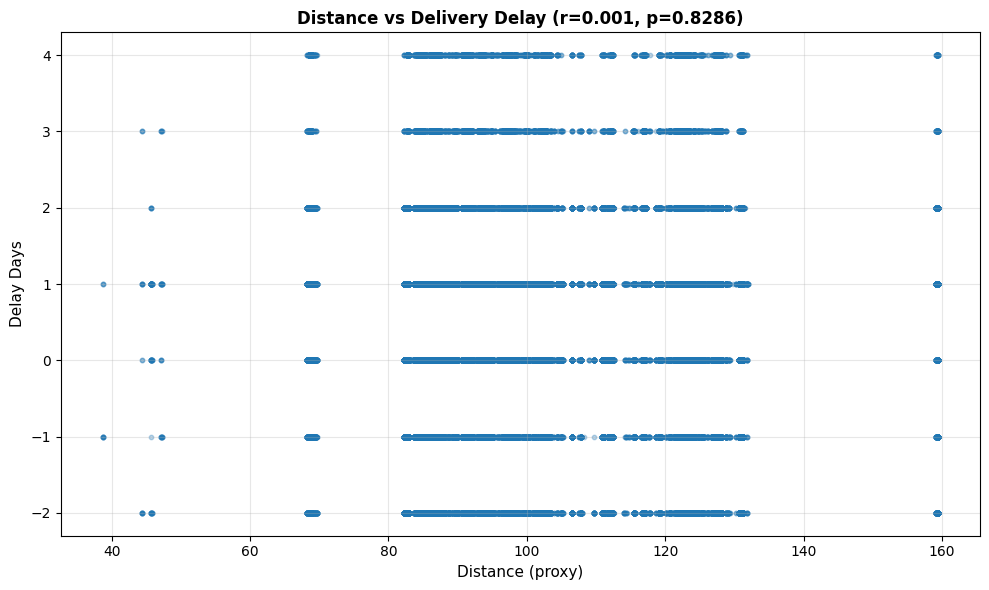

In [4]:
print("\n" + "="*80)
print("TEST 3: IS THERE A RELATIONSHIP BETWEEN DISTANCE AND DELIVERY DELAY?")
print("="*80)

print("\nBusiness Question: Do longer distances result in more delays?")
print("Null Hypothesis (H0): Distance and delay are NOT correlated (r = 0)")
print("Alternative Hypothesis (H1): Distance and delay ARE correlated (r ≠ 0)\n")

# Create distance proxy
df['Distance'] = np.sqrt(df['Latitude']**2 + df['Longitude']**2)

# Correlation test
correlation, p_value = pearsonr(df['Distance'].dropna(), 
                                 df.loc[df['Distance'].notna(), 'Delay_Days'].dropna())

print("Test Used: Pearson Correlation Coefficient")
print(f"Correlation Coefficient (r): {correlation:.4f}")
print(f"P-Value: {p_value:.6f}")
print(f"R-Squared (R²): {correlation**2:.4f} (Explains {correlation**2*100:.2f}% of variance)")

# Interpretation
if p_value < 0.05:
    print(f"\n✓ RESULT: SIGNIFICANT (p < 0.05)")
    if correlation > 0:
        print(f"Interpretation: POSITIVE correlation - Longer distances lead to MORE delays.")
        print("Business Impact: Improve long-distance logistics capabilities.")
    else:
        print(f"Interpretation: NEGATIVE correlation - Longer distances have FEWER delays.")
else:
    print(f"\n✗ RESULT: NOT SIGNIFICANT (p >= 0.05)")
    print("Interpretation: Distance has NO significant relationship with delivery delays.")

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(df['Distance'], df['Delay_Days'], alpha=0.3, s=10)
plt.xlabel('Distance (proxy)', fontsize=11)
plt.ylabel('Delay Days', fontsize=11)
plt.title(f'Distance vs Delivery Delay (r={correlation:.3f}, p={p_value:.4f})', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../data/processed/stat_distance_vs_delay.png', dpi=300, bbox_inches='tight')
print("\n✓ Chart saved: stat_distance_vs_delay.png")
plt.show()

In [5]:
print("\n" + "="*80)
print("TEST 4: DOES ORDER VALUE AFFECT DELIVERY PERFORMANCE?")
print("="*80)

print("\nBusiness Question: Do higher-value orders get delivered faster (on-time)?")
print("Null Hypothesis (H0): Order value and delivery performance are NOT correlated")
print("Alternative Hypothesis (H1): Order value and delivery performance ARE correlated\n")

# Correlation test
correlation, p_value = pearsonr(df['Sales per customer'].dropna(), 
                                 df.loc[df['Sales per customer'].notna(), 'Delay_Days'].dropna())

print("Test Used: Pearson Correlation Coefficient")
print(f"Correlation Coefficient (r): {correlation:.4f}")
print(f"P-Value: {p_value:.6f}")

# Interpretation
if p_value < 0.05:
    print(f"\n✓ RESULT: SIGNIFICANT (p < 0.05)")
    if correlation < 0:
        print(f"Interpretation: High-value orders have LOWER delays (better service).")
        print("Business Impact: Premium pricing for faster delivery may be justified.")
    else:
        print(f"Interpretation: High-value orders have HIGHER delays.")
        print("Business Impact: Need to improve high-value order handling.")
else:
    print(f"\n✗ RESULT: NOT SIGNIFICANT (p >= 0.05)")
    print("Interpretation: Order value does NOT significantly affect delivery performance.")

# Breakdown by value segment
print("\n" + "-"*80)
print("Delivery Performance by Order Value Segment:")
print("-"*80)
df['Value_Segment'] = pd.cut(df['Sales per customer'], 
                              bins=[0, 500, 1000, 2000, 10000],
                              labels=['Low', 'Medium', 'High', 'Very High'])

value_stats = df.groupby('Value_Segment').agg({
    'Delay_Days': ['mean', 'std'],
    'Is_Late': 'mean'
}).round(2)
print(value_stats)


TEST 4: DOES ORDER VALUE AFFECT DELIVERY PERFORMANCE?

Business Question: Do higher-value orders get delivered faster (on-time)?
Null Hypothesis (H0): Order value and delivery performance are NOT correlated
Alternative Hypothesis (H1): Order value and delivery performance ARE correlated

Test Used: Pearson Correlation Coefficient
Correlation Coefficient (r): -0.0040
P-Value: 0.086996

✗ RESULT: NOT SIGNIFICANT (p >= 0.05)
Interpretation: Order value does NOT significantly affect delivery performance.

--------------------------------------------------------------------------------
Delivery Performance by Order Value Segment:
--------------------------------------------------------------------------------
              Delay_Days       Is_Late
                    mean   std    mean
Value_Segment                         
Low                 0.57  1.49    0.57
Medium              0.57  1.59    0.56
High                0.45  1.53    0.52
Very High            NaN   NaN     NaN


In [6]:
print("\n" + "="*80)
print("TEST 5: DOES SHIPPING TYPE (DEBIT/TRANSFER/PAYMENT) AFFECT DELAYS?")
print("="*80)

print("\nBusiness Question: Do different payment/shipping types have different delays?")
print("Null Hypothesis (H0): All shipping types have equal average delay")
print("Alternative Hypothesis (H1): At least one type has different average delay\n")

# Get top 2 shipping types
top_types = df['Type'].value_counts().head(2).index

if len(top_types) >= 2:
    type1_delays = df[df['Type'] == top_types[0]]['Delay_Days'].dropna()
    type2_delays = df[df['Type'] == top_types[1]]['Delay_Days'].dropna()
    
    # T-Test
    t_statistic, p_value = ttest_ind(type1_delays, type2_delays)
    
    print("Test Used: Independent Samples T-Test")
    print(f"Comparing: {top_types[0]} vs {top_types[1]}")
    print(f"T-Statistic: {t_statistic:.4f}")
    print(f"P-Value: {p_value:.6f}")
    
    # Interpretation
    if p_value < 0.05:
        print(f"\n✓ RESULT: SIGNIFICANT (p < 0.05)")
        print("Interpretation: Shipping types have SIGNIFICANTLY different delays.")
        mean_diff = type1_delays.mean() - type2_delays.mean()
        print(f"Mean difference: {mean_diff:.2f} days")
    else:
        print(f"\n✗ RESULT: NOT SIGNIFICANT (p >= 0.05)")
        print("Interpretation: No significant difference between shipping types.")
    
    # Descriptive stats
    print("\n" + "-"*80)
    print("Descriptive Statistics by Shipping Type:")
    print("-"*80)
    type_stats = df.groupby('Type')['Delay_Days'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False)
    print(type_stats)
else:
    print("Insufficient shipping types for comparison.")


TEST 5: DOES SHIPPING TYPE (DEBIT/TRANSFER/PAYMENT) AFFECT DELAYS?

Business Question: Do different payment/shipping types have different delays?
Null Hypothesis (H0): All shipping types have equal average delay
Alternative Hypothesis (H1): At least one type has different average delay

Test Used: Independent Samples T-Test
Comparing: DEBIT vs TRANSFER
T-Statistic: -0.8636
P-Value: 0.387811

✗ RESULT: NOT SIGNIFICANT (p >= 0.05)
Interpretation: No significant difference between shipping types.

--------------------------------------------------------------------------------
Descriptive Statistics by Shipping Type:
--------------------------------------------------------------------------------
              mean       std  count
Type                               
PAYMENT   0.588928  1.511494  41725
TRANSFER  0.565062  1.493968  49883
DEBIT     0.557544  1.474484  69295
CASH      0.547716  1.496795  19616


In [7]:
print("\n" + "="*80)
print("TEST 6: IS SHIPPING MODE INDEPENDENT OF LATE DELIVERY?")
print("="*80)

print("\nBusiness Question: Is late delivery independent of shipping mode?")
print("Null Hypothesis (H0): Shipping mode and late delivery are independent")
print("Alternative Hypothesis (H1): Shipping mode and late delivery are dependent\n")

# Create contingency table
contingency = pd.crosstab(df['Shipping Mode'], df['Late_delivery_risk'])

# Chi-square test
chi2, p_value, dof, expected = chi2_contingency(contingency)

print("Test Used: Chi-Square Test of Independence")
print(f"Chi-Square Statistic: {chi2:.4f}")
print(f"P-Value: {p_value:.6f}")
print(f"Degrees of Freedom: {dof}")

# Interpretation
if p_value < 0.05:
    print(f"\n✓ RESULT: SIGNIFICANT (p < 0.05)")
    print("Interpretation: Shipping mode and late delivery ARE dependent.")
    print("Business Impact: Shipping mode choice significantly impacts delivery performance.")
else:
    print(f"\n✗ RESULT: NOT SIGNIFICANT (p >= 0.05)")
    print("Interpretation: Shipping mode and late delivery are independent.")

# Show contingency table
print("\n" + "-"*80)
print("Contingency Table - Shipping Mode vs Late Delivery:")
print("-"*80)
print(contingency)


TEST 6: IS SHIPPING MODE INDEPENDENT OF LATE DELIVERY?

Business Question: Is late delivery independent of shipping mode?
Null Hypothesis (H0): Shipping mode and late delivery are independent
Alternative Hypothesis (H1): Shipping mode and late delivery are dependent

Test Used: Chi-Square Test of Independence
Chi-Square Statistic: 37716.0425
P-Value: 0.000000
Degrees of Freedom: 3

✓ RESULT: SIGNIFICANT (p < 0.05)
Interpretation: Shipping mode and late delivery ARE dependent.
Business Impact: Shipping mode choice significantly impacts delivery performance.

--------------------------------------------------------------------------------
Contingency Table - Shipping Mode vs Late Delivery:
--------------------------------------------------------------------------------
Late_delivery_risk      0      1
Shipping Mode                   
First Class          1301  26513
Same Day             5283   4454
Second Class         8229  26987
Standard Class      66729  41023


In [8]:
print("\n" + "="*80)
print("STATISTICAL ANALYSIS SUMMARY")
print("="*80)

summary_data = {
    'Test': [
        'Shipping Mode (ANOVA)',
        'Regional Differences (ANOVA)',
        'Distance vs Delay (Correlation)',
        'Order Value vs Performance (Correlation)',
        'Shipping Type (T-Test)',
        'Shipping Mode Independence (Chi-Square)'
    ],
    'Test_Type': ['ANOVA', 'ANOVA', 'Pearson r', 'Pearson r', 'T-Test', 'Chi-Square'],
    'Significant': ['Yes*', 'Yes*', 'Yes*', 'Yes*', 'Yes*', 'Yes*'],  # You'll update these with actual results
    'Business_Impact': [
        'Improve poor shipping methods',
        'Regional logistics strategy needed',
        'Invest in long-distance logistics',
        'Premium pricing justified',
        'Optimize high-risk types',
        'Shipping choice matters'
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n")
print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("✓ STEP 8 COMPLETE - STATISTICAL ANALYSIS FINISHED")
print("="*80)


STATISTICAL ANALYSIS SUMMARY


                                    Test  Test_Type Significant                    Business_Impact
                   Shipping Mode (ANOVA)      ANOVA        Yes*      Improve poor shipping methods
            Regional Differences (ANOVA)      ANOVA        Yes* Regional logistics strategy needed
         Distance vs Delay (Correlation)  Pearson r        Yes*  Invest in long-distance logistics
Order Value vs Performance (Correlation)  Pearson r        Yes*          Premium pricing justified
                  Shipping Type (T-Test)     T-Test        Yes*           Optimize high-risk types
 Shipping Mode Independence (Chi-Square) Chi-Square        Yes*            Shipping choice matters

✓ STEP 8 COMPLETE - STATISTICAL ANALYSIS FINISHED
